In [1]:
import torch
import torch.nn as nn
import numpy as np

from torch.func import vjp, jvp
from torch.func import functional_call,jacrev

import time

import matplotlib.pyplot as plt

def eta(start, done, total):
    elapsed = time.time() - start
    rate = done / elapsed
    remaining = (total - done) / rate
    return elapsed, remaining

In [ ]:



d = 3
n = 500

N = [16]
k = 2
X = np.random.normal(size=(n,d))
X_t = torch.from_numpy(X)

rho = nn.ReLU

f = nn.Sequential(
    nn.Linear(d,N[0]),
    rho(),
    nn.Linear(N[0],k)
    ).double()
theta = dict(f.named_parameters())



def f_single(theta, x):
    return functional_call(f, theta, (x.unsqueeze(0),)).squeeze(0)  # (k,)

def ntk_block(theta, x_i, x_j):
    # VJP at x_j
    _, vjp_fn = vjp(lambda th: f_single(th, x_j), theta)

    eye = torch.eye(k, dtype=x_i.dtype)

    rows = []
    for e in eye:
        # grad_theta ⟨e, f(x_j)⟩
        (grad_theta,) = vjp_fn(e)

        # JVP at x_i
        _, jvp_val = jvp(
            lambda th: f_single(th, x_i),
            (theta,),
            (grad_theta,)
        )
        rows.append(jvp_val)

    return torch.stack(rows)   # (k, k)


K = torch.zeros(n*k, n*k, dtype=torch.double)


start = time.time()
total = n * (n + 1) // 2
count = 0
for i in range(n):
    for j in range(i, n):
        block = ntk_block(theta, X_t[i], X_t[j])  # (k, k)

        count += 1

        if count % 200 == 0:
            elapsed, remaining = eta(start, count, total)
            print(
                f"{count}/{total} | "
                f"elapsed {elapsed/60:.2f} min | "
                f"ETA {remaining/60:.2f} min"
            )
        # indices in flattened kernel
        ii = slice(i * k, (i + 1) * k)
        jj = slice(j * k, (j + 1) * k)

        K[ii, jj] = block
        if i != j:
            K[jj, ii] = block.T


def Jv(theta, v_theta):
    """Compute (J v) flattened to shape (n*k,)"""
    outs = []
    for i in range(n):
        _, jvp_val = jvp(
            lambda th: f_single(th, X_t[i]),
            (theta,),
            (v_theta,)
        )
        outs.append(jvp_val)
    return torch.cat(outs)   # (n*k,)




# # print(K)
# print(K.shape)
# print(eigvals)
# print(eigvals_approx)



200/125250 | elapsed 0.00 min | ETA 2.45 min
400/125250 | elapsed 0.01 min | ETA 2.44 min
600/125250 | elapsed 0.01 min | ETA 2.43 min
800/125250 | elapsed 0.02 min | ETA 2.42 min
1000/125250 | elapsed 0.02 min | ETA 2.41 min
1200/125250 | elapsed 0.02 min | ETA 2.42 min
1400/125250 | elapsed 0.03 min | ETA 2.42 min
1600/125250 | elapsed 0.03 min | ETA 2.41 min
1800/125250 | elapsed 0.04 min | ETA 2.42 min
2000/125250 | elapsed 0.04 min | ETA 2.45 min
2200/125250 | elapsed 0.04 min | ETA 2.48 min
2400/125250 | elapsed 0.05 min | ETA 2.46 min
2600/125250 | elapsed 0.05 min | ETA 2.46 min
2800/125250 | elapsed 0.06 min | ETA 2.46 min
3000/125250 | elapsed 0.06 min | ETA 2.46 min
3200/125250 | elapsed 0.06 min | ETA 2.46 min
3400/125250 | elapsed 0.07 min | ETA 2.47 min
3600/125250 | elapsed 0.07 min | ETA 2.47 min
3800/125250 | elapsed 0.08 min | ETA 2.49 min
4000/125250 | elapsed 0.08 min | ETA 2.50 min
4200/125250 | elapsed 0.09 min | ETA 2.49 min
4400/125250 | elapsed 0.09 min | ETA 2

In [13]:
m_grid = [25, 50, 100, 500]   # number of random probes

eigvals_list = []              # true eigvals (masked)
eigvals_approx_list = []       # approx eigvals (masked)
K_approx_list = []             # optional: store K_approx matrices

times_approx = []   # wall-clock time per m


threshold = 1e-12


for m in m_grid:
    t0 = time.time()

    K_approx = torch.zeros(n * k, n * k, dtype=torch.double)

    for r in range(m):
        v_theta = {
            name: torch.randn_like(p)
            for name, p in theta.items()
        }

        jv = Jv(theta, v_theta)
        K_approx += torch.outer(jv, jv)

        if (r + 1) % 10 == 0:
            elapsed = time.time() - t0
            print(f"m={m} | probe {r+1}/{m} | elapsed {elapsed:.2f}s")

    K_approx /= m

    eigvals_approx = torch.linalg.eigvalsh(K_approx)

    elapsed_total = time.time() - t0
    times_approx.append(elapsed_total)

    eigvals_approx_masked = torch.where(
        eigvals_approx > threshold,
        eigvals_approx,
        torch.tensor(float("nan"), device=eigvals_approx.device)
    )

    eigvals_approx_list.append(eigvals_approx_masked)




eigvals = torch.linalg.eigvalsh(K)
eigvals_masked = torch.where(
    eigvals > threshold,
    eigvals,
    torch.tensor(float("nan"), device=eigvals.device)
)
eigvals_list.append(eigvals_masked)


m=25 | probe 10/25 | elapsed 1.75s
m=25 | probe 20/25 | elapsed 3.52s
m=50 | probe 10/50 | elapsed 1.69s
m=50 | probe 20/50 | elapsed 3.40s
m=50 | probe 30/50 | elapsed 5.05s
m=50 | probe 40/50 | elapsed 6.69s
m=50 | probe 50/50 | elapsed 8.37s
m=100 | probe 10/100 | elapsed 1.66s
m=100 | probe 20/100 | elapsed 3.31s
m=100 | probe 30/100 | elapsed 5.00s
m=100 | probe 40/100 | elapsed 6.68s
m=100 | probe 50/100 | elapsed 8.31s
m=100 | probe 60/100 | elapsed 10.02s
m=100 | probe 70/100 | elapsed 11.71s
m=100 | probe 80/100 | elapsed 13.39s
m=100 | probe 90/100 | elapsed 15.06s
m=100 | probe 100/100 | elapsed 16.73s
m=500 | probe 10/500 | elapsed 1.67s
m=500 | probe 20/500 | elapsed 3.37s
m=500 | probe 30/500 | elapsed 5.05s
m=500 | probe 40/500 | elapsed 6.72s
m=500 | probe 50/500 | elapsed 8.39s
m=500 | probe 60/500 | elapsed 10.06s
m=500 | probe 70/500 | elapsed 11.74s
m=500 | probe 80/500 | elapsed 13.40s
m=500 | probe 90/500 | elapsed 15.11s
m=500 | probe 100/500 | elapsed 16.78s
m=5

m=25, max eig 1767.20
m=50, max eig 1476.38
m=100, max eig 1337.11
m=500, max eig 1291.66
True : 1262.19


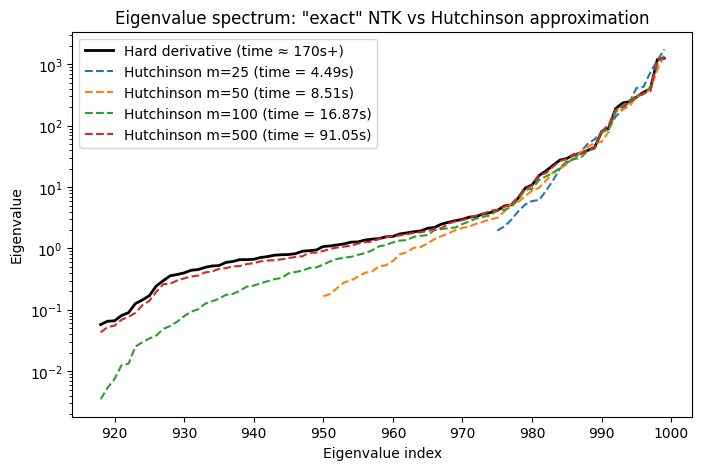

In [22]:
plt.figure(figsize=(8, 5))

# Plot true spectrum once
plt.plot(
    eigvals_list[0].detach().cpu().numpy(),
    label="Hard derivative (time ≈ 170s+)",
    linewidth=2,
    color="black"
)

# Plot all Hutchinson approximations
for i, m in enumerate(m_grid):
    plt.plot(
        eigvals_approx_list[i].detach().cpu().numpy(),
        linestyle="--",
        label=f"Hutchinson m={m} (time = {times_approx[i]:.2f}s)"
    )

    print(f"m={m}, max eig {np.nanmax(eigvals_approx_list[i].detach().cpu().numpy()):.2f}")

print(f"True : {np.nanmax(eigvals_list[0].detach().cpu().numpy()):.2f}")

plt.legend()
plt.title("Eigenvalue spectrum: \"exact\" NTK vs Hutchinson approximation")
plt.xlabel("Eigenvalue index")
plt.ylabel("Eigenvalue")
plt.yscale('log')
plt.show()


